# Exercises

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import numpy as np
import sys
import os
sys.path.append(os.path.abspath("code"))
from utils import download_data
import lfp_functions as lf

# sns.set_theme(context='notebook',style='white',font_scale=1.5,
#               rc = {'axes.spines.top':False,'axes.spines.right':False,
#                      'image.cmap':plt.cm.jet})

sns.set_theme(context='notebook',style='white',font_scale=1.5,
               rc = {'axes.spines.top':False,'axes.spines.right':False})



## Exercise 1: explore filter parameters
---
In this exercises you will explore how different parameters affect the filtering process.
- Import the data form `data/moving_lfp.pickle` (the file is already on your machine if you run the `download_data()` cell in the main lesson)
- Take a few seconds of the data, and filter them in different frequency bands. Plot the resulting singal.
  Fix the central frequency and play with the width of the band, then try to change the central frequency of the band.
- Change the order of the filter, keeping the frequency band fixed. How does the filtered signal change? How does the computing time change? (You can try to quantify the computing time with the jupyter magic command [`%timeit`](https://docs.python.org/3/library/timeit.html) )
- Comment on what you see

Loaded 600.133 seconds of LFP, sampled at 1000.0 Hz, focusing on a slice of 2.0 seconds
Below I plot the first 2 of the signal.


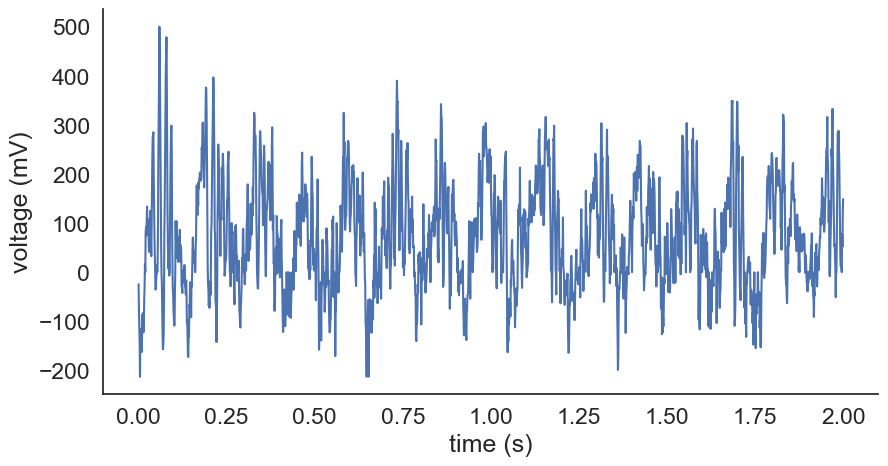

In [25]:
# Download lesson data
download_data('https://surfdrive.surf.nl/files/index.php/s/9nY01qMimFLez40')

# Loading the data in
with open('data/moving_lfp.pickle', 'rb') as handle:
    lfp_data = pickle.load(handle)

lfp = lfp_data['lfp']
sampling_rate = lfp_data['sampling_rate']
few_seconds = 2                                     # Added line to parameterize how many seconds of signal we take 
few_seconds_data = int(sampling_rate*few_seconds)   # Calculates how many data points we need based on how many seconds of the signal we want
lfp_slice = lfp_data['lfp'][:few_seconds_data]            # Redefines lfp such that lesson code can be utilized as easily as possible for the rest of the exercises

print(f'Loaded {len(lfp)/sampling_rate} seconds of LFP, sampled at {sampling_rate} Hz, focusing on a slice of {len(lfp_slice)/sampling_rate} seconds')
print(f'Below I plot the first {few_seconds} of the signal.')

plt.figure(figsize=(10,5))
plt.plot(np.linspace(0,int(few_seconds),int(few_seconds*sampling_rate)),lfp_slice);  # Modified such that plotting will adapt to however many seconds of data we want to plot
plt.xlabel('time (s)');
plt.ylabel('voltage (mV)');


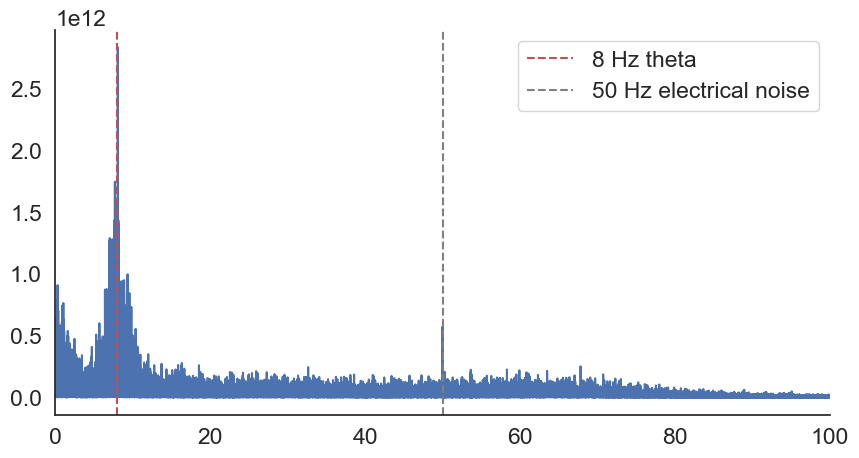

In [27]:
from scipy.fft import fft, fftfreq

n_samples = len(lfp)
sample_dt = 1. / sampling_rate

# we subtract the mean to get rid of the 0 frequency component in the spectrum
centered_lfp = lfp - np.mean(lfp)

transformed_signal = fft(centered_lfp) 

frequencies = fftfreq(n_samples,sample_dt) 

transformed_signal = transformed_signal[:n_samples//2]
frequencies = frequencies[:n_samples//2]

power = abs(transformed_signal)**2

plt.figure(figsize = (10,5))
plt.plot(frequencies,power)
plt.xlim([0,100]) # restrict to 
plt.axvline(x=8 ,c='r',linestyle='--',label='8 Hz theta')
plt.axvline(x=50 ,c='grey',linestyle='--',label='50 Hz electrical noise')

plt.legend()


Investigating the effect of bandwidth, focusing on theta band

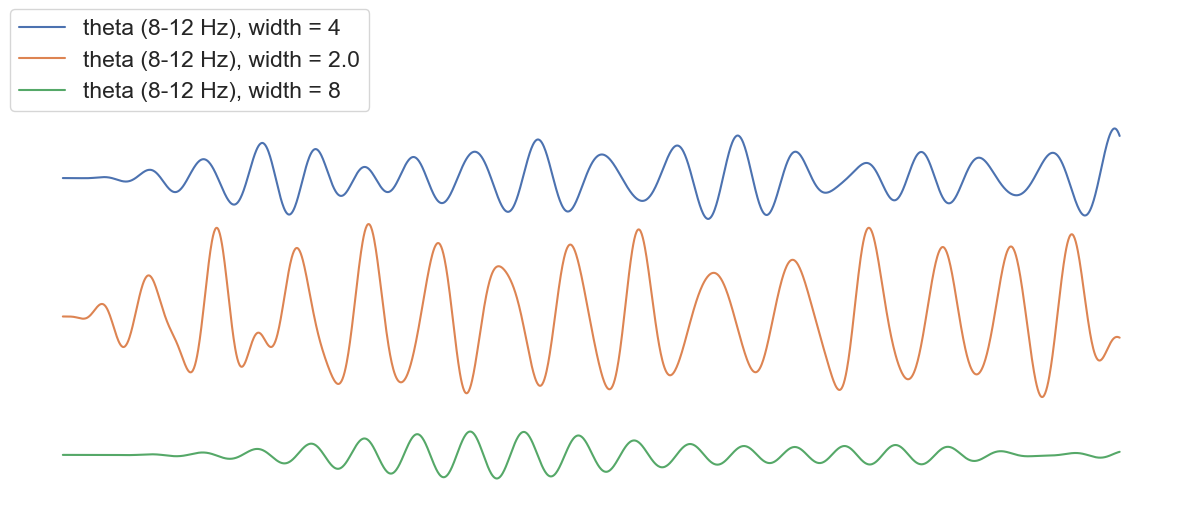

In [44]:
f_theta_central = 10 
width_theta_central = 4

theta_lfp_orig = lf.bandpass_filter(lfp,low_f=8,high_f=12, sampling_rate=sampling_rate)
theta_lfp_wider = lf.bandpass_filter(lfp, low_f = f_theta_central - width_theta_central, high_f = f_theta_central + width_theta_central, sampling_rate=sampling_rate)
theta_lfp_narrower = lf.bandpass_filter(lfp, low_f = f_theta_central - width_theta_central/4, high_f = f_theta_central + width_theta_central/4, sampling_rate=sampling_rate)

plot_offset = 200 #to plot the signal on different lines

plt.figure(figsize=(15,5))
plt.plot(theta_lfp_orig[:2000]+2*plot_offset,label= f'theta (8-12 Hz), width = {width_theta_central}')
plt.plot(theta_lfp_wider[:2000]+plot_offset,label = f'theta (8-12 Hz), width = {width_theta_central/2}')
plt.plot(theta_lfp_narrower[:2000],label = f'theta (8-12 Hz), width = {width_theta_central*2}')

plt.axis('off')
plt.legend(loc=(0,1))

now shifting the central frequency

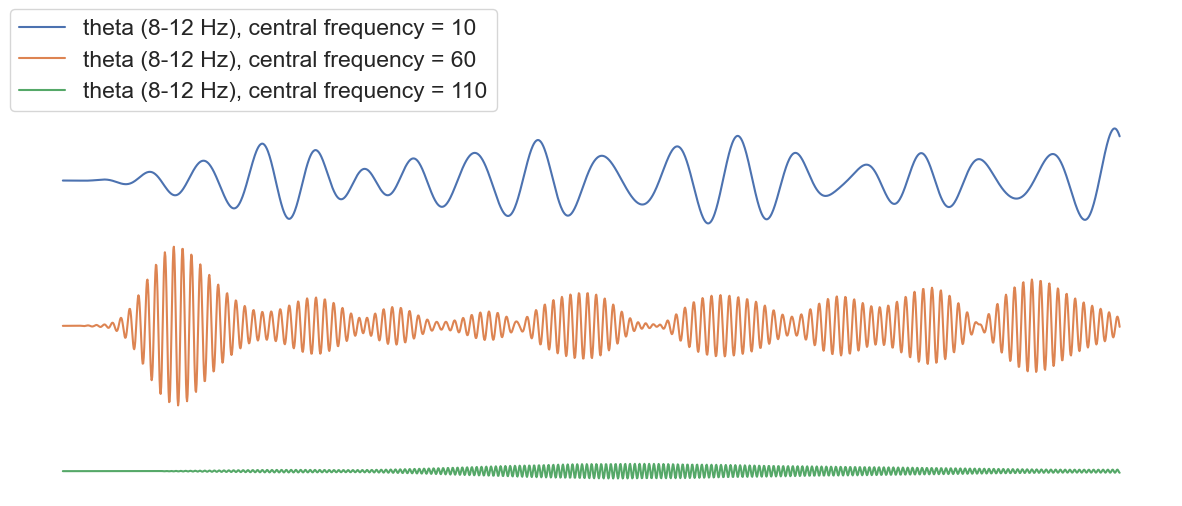

In [45]:
f_theta_central = 10 
width_theta_central = 4 # As was used originally for the theta oscillations 

theta_lfp_orig = lf.bandpass_filter(lfp, low_f = f_theta_central - width_theta_central/2, high_f = f_theta_central + width_theta_central/2, sampling_rate=sampling_rate)
theta_lfp_wider = lf.bandpass_filter(lfp, low_f = f_theta_central+50 - width_theta_central, high_f = f_theta_central+50 + width_theta_central, sampling_rate=sampling_rate)
theta_lfp_narrower = lf.bandpass_filter(lfp, low_f = f_theta_central+100 - width_theta_central/4, high_f = f_theta_central+100 + width_theta_central/4, sampling_rate=sampling_rate)

plot_offset = 200 #to plot the signal on different lines

plt.figure(figsize=(15,5))
plt.plot(theta_lfp_orig[:2000]+2*plot_offset,label= f'theta (8-12 Hz), central frequency = {f_theta_central}')
plt.plot(theta_lfp_wider[:2000]+plot_offset,label = f'theta (8-12 Hz), central frequency = {f_theta_central + 50}')
plt.plot(theta_lfp_narrower[:2000],label = f'theta (8-12 Hz), central frequency = {f_theta_central +100}')

plt.axis('off')
plt.legend(loc=(0,1))

Inspecting the effect of filter order, focusing on theta frequency band

Text(0, 0.5, 'voltage (mV)')

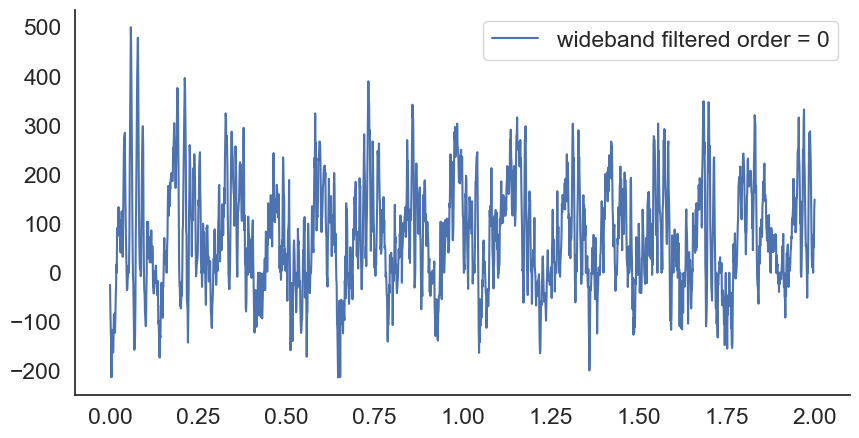

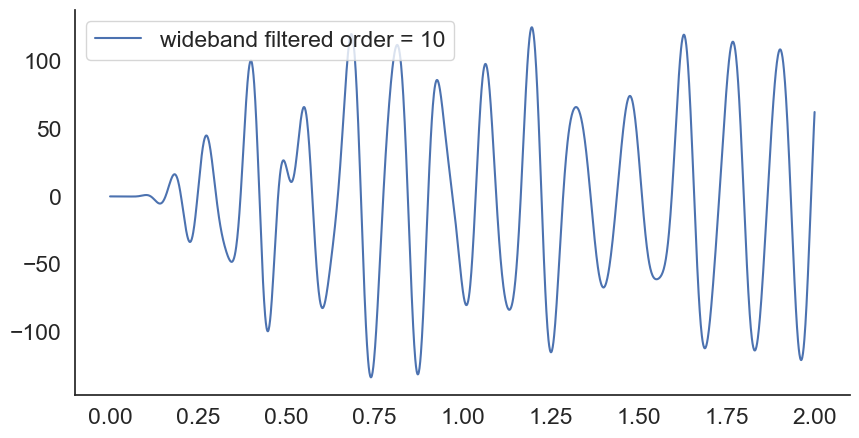

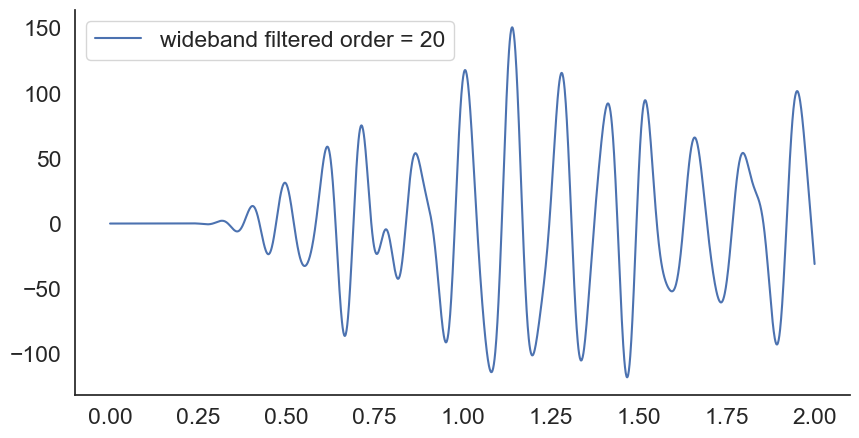

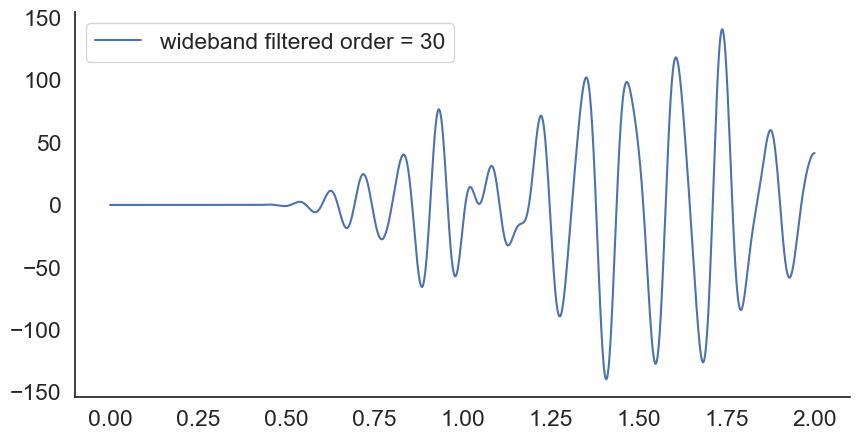

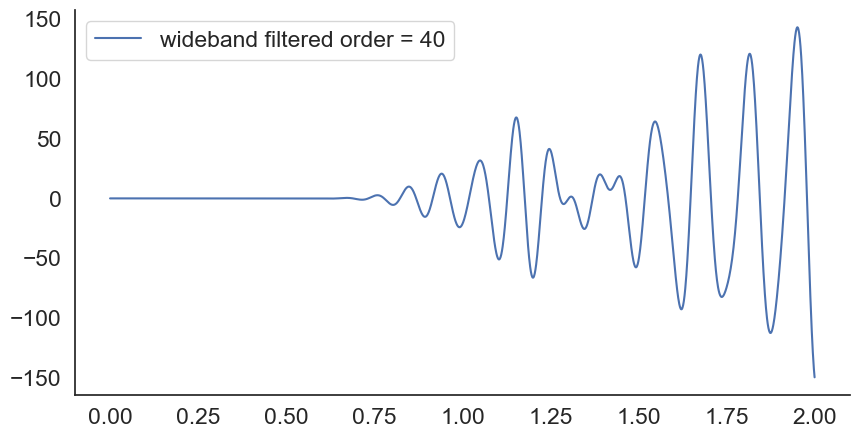

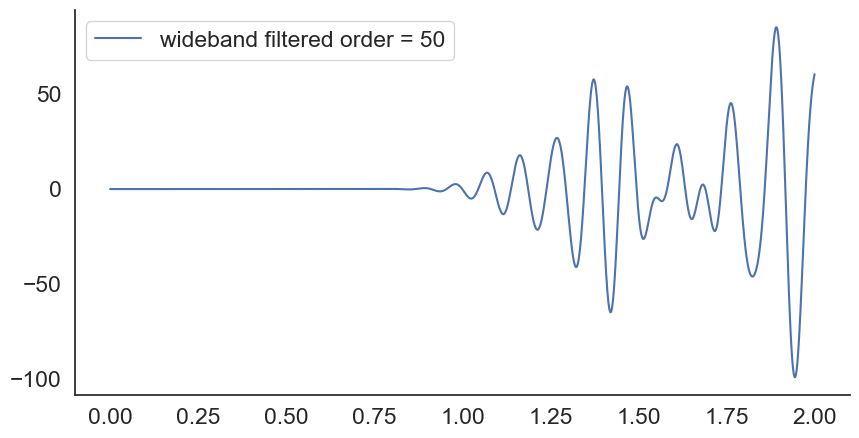

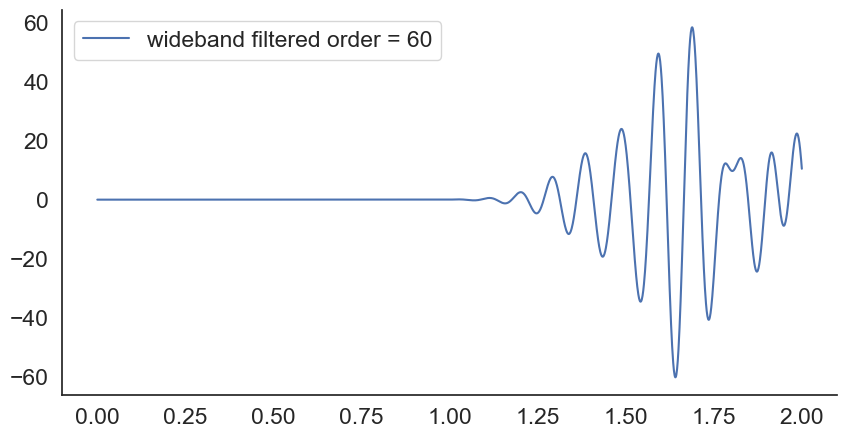

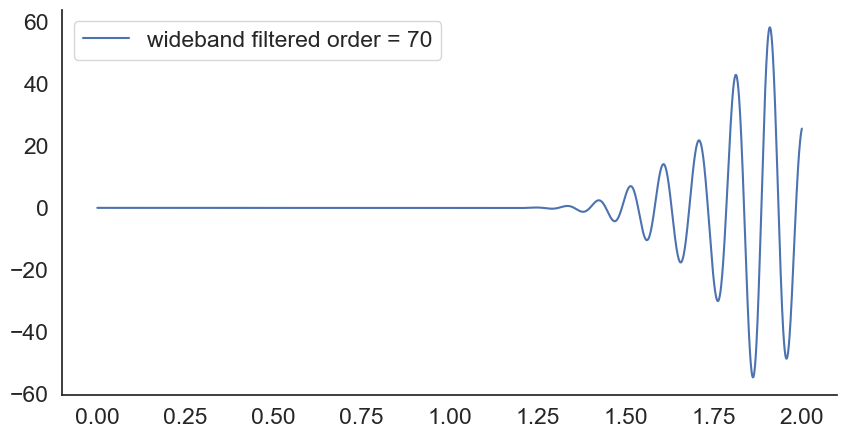

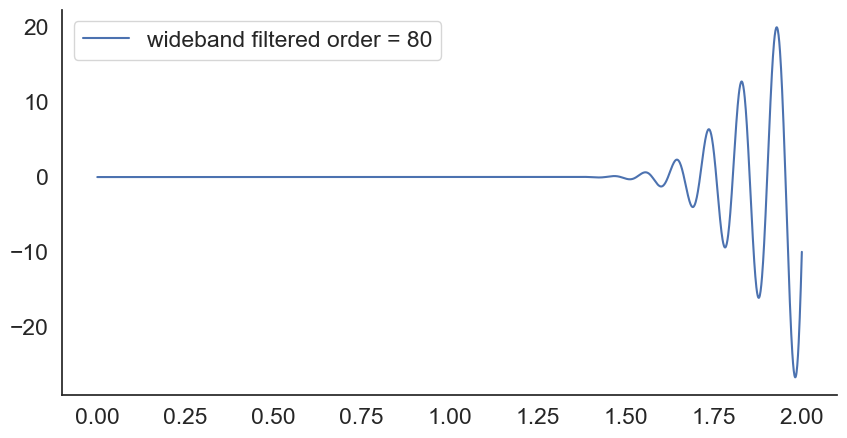

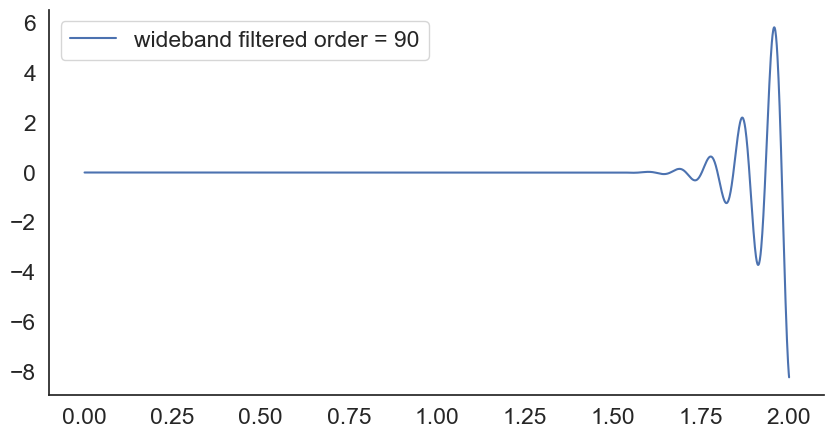

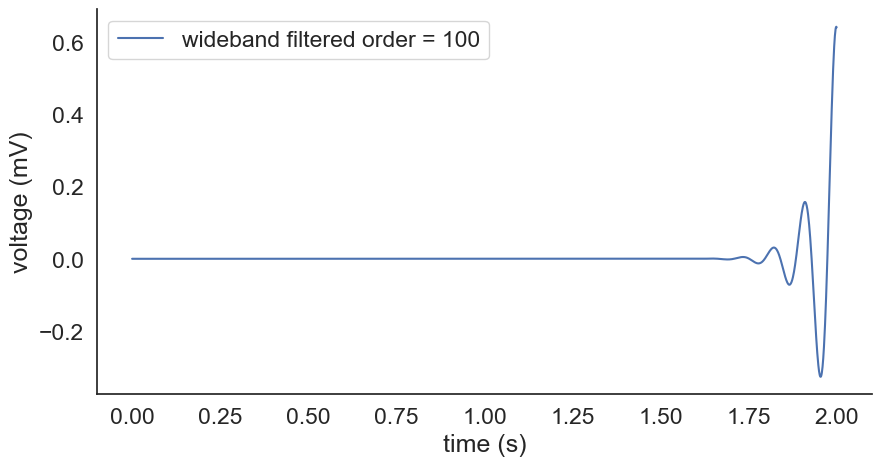

In [ ]:
from scipy.signal import butter
from scipy.signal import sosfilt

# filter_order = 10 #the higher the order, the sharper the filter frequency response, 
                 #but with more computations and potental numerical instability
low_f = f_theta_central- width_theta_central
high_f = f_theta_central + width_theta_central

filter_orders = np.arange(0,101,10)

for filter_order in filter_orders:
    #define filter object
    filter = butter(filter_order,[low_f,high_f],
                    btype='band', 
                    output='sos', 
                    fs=sampling_rate)
                    
    #apply filter to lfp       
    wideband_lfp = sosfilt(filter, lfp)



    plt.figure(figsize=(10,5))
    plt.plot(np.linspace(0,2,2000),wideband_lfp[:2000],label = f'wideband filtered order = {filter_order}')
    #plt.plot(np.linspace(0,2,2000),lfp[:2000],label='raw signal')
    plt.legend()


plt.xlabel('time (s)')
plt.ylabel('voltage (mV)')


## Exercise 2: wavelet transform with real wavelets
---
In this exercises you will explore the difference between real and complex wavelets in the continous wavelet transform.
- Import the data form `data/moving_lfp.pickle`
- Select a period of a few seconds of the signal and compute the spectrogram. 
  Try the wavelet transform with wavelet `mexh` (mexican hat),`gaus` (gaussian) and `morl` (morlet). These are all real wavelets.
- What differences do you see with respect to the spectrum computed with the complex Morlet tranform ? Comment on why do you think this might be the case.

## Exercise 3: REM sleep detection
---
Mammalian sleep is organized in different phases. [Rapid Eye Movement (REM) sleep](https://en.wikipedia.org/wiki/Rapid_eye_movement_sleep) is a well studied phase, with clear markers that make it detectable from LFP data. One of the most used marker is the ratio (or difference) between the oscillatory power in the theta and delta bands in the hippocampus. During REM sleep, the former dominates, in a pattern that resembles active behaviour.  
In this exercise we will use the tools we learned about to detect and inspect the REM and non-REM (nREM) phases of sleep in data recorded from the hippocampus of a sleeping mouse.

- Import the data form `data/sleep_lfp.pickle`
- Compute the instantaneous power in the theta (6-10 Hz) and delta (2-4 Hz) frequency bands, for the whole signal.
- z-score the two power signals (subtract the mean and divide by the standard deviation, you can use `scipy.stats.zscore()`)
- Compute and plot the power difference (`theta_power - delta_power`) for the sleep session.
- Compute the REM (power difference $>0.2$) and nREM (power diffewrence $<0.2$) sleep periods.
- Plot examples of REM vs nREM lfp signals (wideband filtered betw. 1 and 200 Hz to get rid of some of the noise).
- Explore how changing the threshold affects the amount of REM sleep detected.